# Decision Tree - Hyperparameter Tuning
In this notebook, we tune the `max_depth` hyperparameter of the Decision Tree Classifier. By iterating through different depths, we plot the training error vs. validation error to find the optimal depth that prevents overfitting, then train and evaluate our final tuned model.


### 1. Load Processed Data
We import the required libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and load the preprocessed training inputs and targets.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_inputs = pd.read_csv('../data/processed/train_inputs.csv')
train_targets = pd.read_csv('../data/processed/train_targets.csv')

### 2. Import DecisionTreeClassifier
We import the decision tree classifier from `sklearn.tree`.


In [30]:
from sklearn.tree import DecisionTreeClassifier

### 3. Define Hyperparameter Tuning Helper
We define a helper function `max_depth_error` that:
1. Fits a decision tree with a specified `max_depth`.
2. Calculates the error rates (1 - accuracy) for both training and validation sets.
3. Returns the results as a dictionary.


In [31]:
def max_depth_error(max_depth):
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(train_inputs, train_targets)
    train_error = 1 - model.score(train_inputs, train_targets)
    validation_error = 1 - model.score(validation_inputs, validation_targets)
    return {'Max_Depth': max_depth, 'train_error': train_error, 'validation_error': validation_error}

### 4. Evaluate Depth Values
We run the helper function for depths from 1 to 20 and store the results in a DataFrame to compare performance.


In [32]:
errors_df = pd.DataFrame([max_depth_error(i) for i in range(1, 21)])
print(errors_df)

    Max_Depth  train_error  validation_error
0           1     0.184315          0.177935
1           2     0.179547          0.172712
2           3     0.170869          0.166560
3           4     0.165707          0.164355
4           5     0.160676          0.159074
5           6     0.156271          0.157275
6           7     0.153312          0.154605
7           8     0.147806          0.157971
8           9     0.140967          0.156636
9          10     0.132996          0.157217
10         11     0.123227          0.158668
11         12     0.113196          0.161976
12         13     0.101790          0.164065
13         14     0.089849          0.166502
14         15     0.078868          0.172364
15         16     0.068251          0.175440
16         17     0.058260          0.176949
17         18     0.048662          0.181475
18         19     0.040237          0.184203
19         20     0.032337          0.187511


### 5. Plot Training vs. Validation Error
We plot the training and validation errors against `max_depth`. The point where the validation error starts increasing or levels off while the training error continues to decrease shows the optimal depth to prevent overfitting.


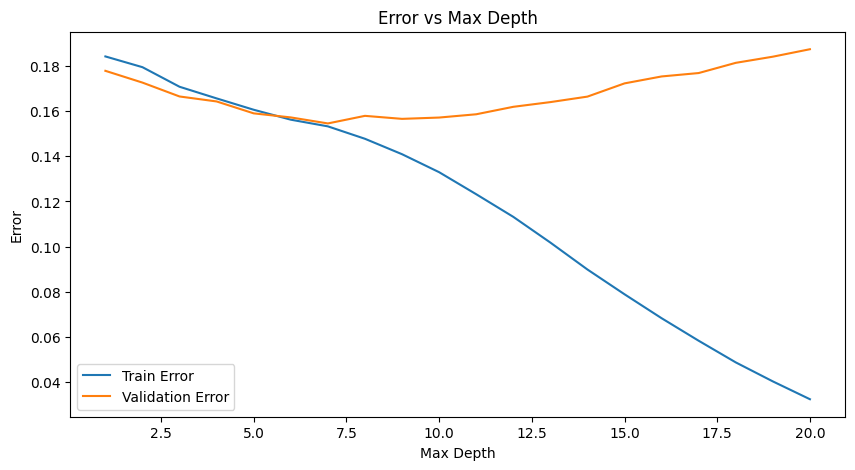

In [33]:
plt.figure(figsize=(10,5))
sns.lineplot(data=errors_df, x='Max_Depth', y='train_error', label='Train Error')
sns.lineplot(data=errors_df, x='Max_Depth', y='validation_error', label='Validation Error')
plt.xlabel('Max Depth')
plt.ylabel('Error')
plt.title('Error vs Max Depth')
plt.legend()


### 6. Train and Evaluate Tuned Model
Based on the plot, we select `max_depth=8` as the optimal value. We train our final decision tree classifier, evaluate its accuracy on both the training and validation sets, and print the results.


In [34]:
model = DecisionTreeClassifier(max_depth=8, random_state=42)
model.fit(train_inputs, train_targets)

print(model.score(train_inputs, train_targets))

validation_inputs = pd.read_csv('../data/processed/validation_inputs.csv')
validation_targets = pd.read_csv('../data/processed/validation_targets.csv')

print(model.score(validation_inputs, validation_targets))


0.8521942053582252
0.842028901398642
